In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Stage 15 — Measured stereo, calibration, and uncertainty

Read `lessons/15_lesson.md` and `workbooks/15_workbook.md` first. Predict each result before executing. All outputs here are reference examples, not a grade.

**Evidence boundary:** real static stereo observations are bundled; analytical controls are labeled synthetic. No VGGT checkpoint is run by this notebook.

Source keys: D04, D05, G06, G07

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
from pathlib import Path
import sys, json, time
import numpy as np
import matplotlib.pyplot as plt
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/shape_lab").is_dir())
if str(ROOT / "src") not in sys.path: sys.path.insert(0, str(ROOT / "src"))
from shape_lab.stereo import reference_sample, point_cloud, depth_from_disparity
from shape_lab.geometry import *
from shape_lab.display import save_json, show_and_save, plot_diagram
left, right, reference_disparity, calibration = reference_sample()
OUT = ROOT / "reports" / "stage_15"
OUT.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(20260920)
print("Real data:", left.shape, right.shape, reference_disparity.shape)
print("Data source:", calibration["source"])

Real data: (500, 741, 3) (500, 741, 3) (500, 741)
Data source: scikit-image 0.26.0 stereo_motorcycle; Middlebury 2014


## 1. Inspect the real stereo pair
The pair is already rectified. We did not estimate that rectification. The reference disparity and supplied calibration are evaluation/reference assets, not inputs to our correspondence search.

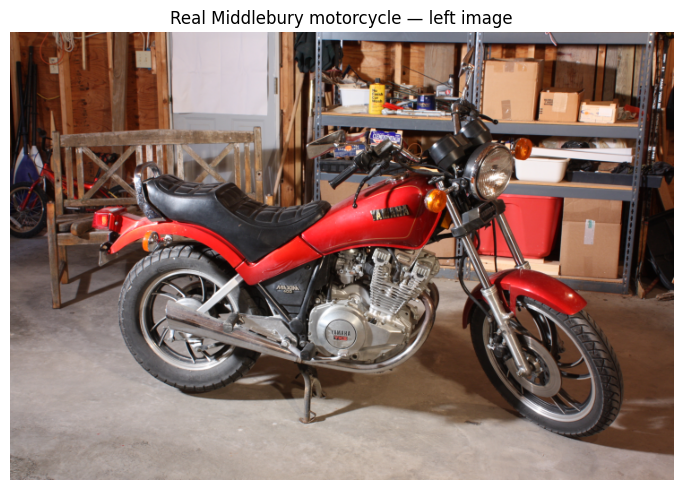

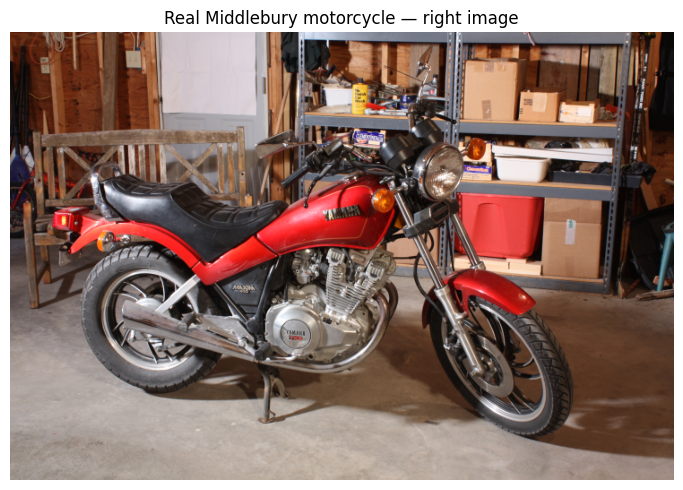

Finite reference disparity: 343274 of 370500
Principal point difference (px): 31.086


In [3]:
plt.figure(figsize=(8,5)); plt.imshow(left); plt.axis("off"); plt.title("Real Middlebury motorcycle — left image")
show_and_save(OUT / "left_image.png")
plt.figure(figsize=(8,5)); plt.imshow(right); plt.axis("off"); plt.title("Real Middlebury motorcycle — right image")
show_and_save(OUT / "right_image.png")
finite=np.isfinite(reference_disparity)
print("Finite reference disparity:",int(finite.sum()),"of",reference_disparity.size)
print("Principal point difference (px):",calibration["doffs_px"])

## 2. Independent patch matching
The fixed grid, disparity search range and patch radius below are declared demonstration choices, not parameters selected on the reported answers. SAD finds the lowest mean absolute patch difference along a row. It does not solve occlusion, subpixel matching or texture ambiguity.

{
  "eligible": 441,
  "evaluated": 441,
  "coverage": 1.0,
  "mean_absolute_error_px": 6.628794520890632,
  "median_absolute_error_px": 0.49462890625,
  "bad_fraction": 0.31065759637188206,
  "bad_threshold_px": 2.0
}


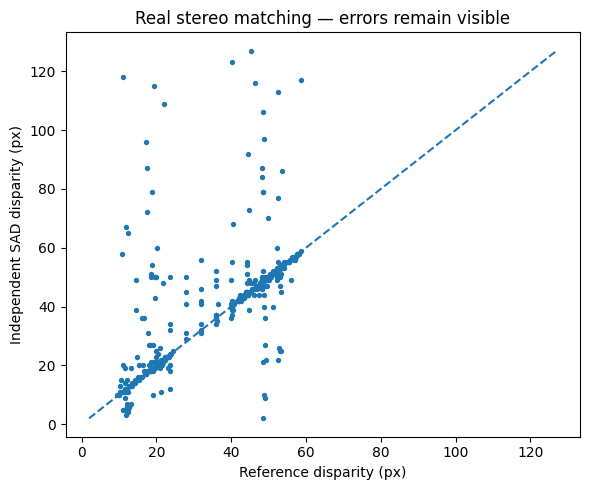

In [4]:
from shape_lab.stereo import sparse_sad, disparity_metrics
rr,cc=np.mgrid[20:480:24,150:720:24]; sample_rc=np.c_[rr.ravel(),cc.ravel()]
predicted,margin=sparse_sad(left,right,sample_rc,max_disparity=128,radius=3)
reference=reference_disparity[sample_rc[:,0],sample_rc[:,1]]
metrics=disparity_metrics(predicted,reference,bad_threshold_px=2)
print(json.dumps(metrics,indent=2))
valid=np.isfinite(reference)&np.isfinite(predicted)
plt.figure(figsize=(6,5)); plt.scatter(reference[valid],predicted[valid],s=8)
lo=float(min(reference[valid].min(),predicted[valid].min())); hi=float(max(reference[valid].max(),predicted[valid].max()))
plt.plot([lo,hi],[lo,hi],linestyle="--")
plt.xlabel("Reference disparity (px)");plt.ylabel("Independent SAD disparity (px)");plt.title("Real stereo matching — errors remain visible")
show_and_save(OUT / "disparity_comparison.png")
np.savez_compressed(OUT / "sad_predictions.npz",source_row_column=sample_rc,predicted_disparity_px=predicted,reference_disparity_px=reference,ambiguity_margin=margin)

## 3. The principal-point correction is necessary
From `uL=f X/Z+cxL` and `uR=f(X-B)/Z+cxR`, derive `d=fB/Z-doffs`. Hence `Z=fB/(d+doffs)`. The comparison below deliberately omits the offset only in the labeled incorrect formula.

In [5]:
f=calibration["focal_px"];B=calibration["baseline_m"];off=calibration["doffs_px"]
z_ref=depth_from_disparity(reference,f,B,off)
z_pred=depth_from_disparity(predicted,f,B,off)
z_wrong=depth_from_disparity(reference,f,B,0)
valid_z=np.isfinite(z_ref)&np.isfinite(z_pred)
depth_mae=float(np.mean(np.abs(z_ref[valid_z]-z_pred[valid_z])))
wrong_valid=np.isfinite(z_ref)&np.isfinite(z_wrong)
wrong_relative=float(np.median(np.abs(z_wrong[wrong_valid]-z_ref[wrong_valid])/z_ref[wrong_valid]))
print("SAD reference-depth MAE (m):",depth_mae)
print("Median relative error from omitting the offset:",wrong_relative)
cloud,rc=point_cloud(reference_disparity,calibration,stride=32)
uvL=rc[:,::-1].astype(float);d=reference_disparity[rc[:,0],rc[:,1]]
uvR=uvL.copy();uvR[:,0]-=d
P1=np.array(calibration["K_left"])@np.eye(4)[:3]
P2=np.array(calibration["K_right"])@np.array(calibration["T_right_left"])[:3]
tri=triangulate_dlt(P1,P2,uvL,uvR)
tri_error=float(np.max(np.linalg.norm(tri-cloud,axis=1)))
assert tri_error<1e-6
assert np.all(tri[:,2]>0)
print("DLT vs analytical stereo, max difference (m):",tri_error)

SAD reference-depth MAE (m): 0.26291384316518346
Median relative error from omitting the offset: 0.760290608540679
DLT vs analytical stereo, max difference (m): 3.384705673477702e-14


## 4. Calibration and uncertainty controls — synthetic
First fit pinhole intrinsics from points whose camera-frame coordinates are known exactly. This is a linear teaching example, **not a complete planar-board calibration algorithm**. Then compare the local depth-uncertainty formula with small synthetic disparity perturbations while holding calibration fixed.

Synthetic held-out intrinsic-fit pixel RMSE: 0.04085150176852518
Conditional depth SD, formula and simulation: 0.004629134204800132 0.004608676096045744


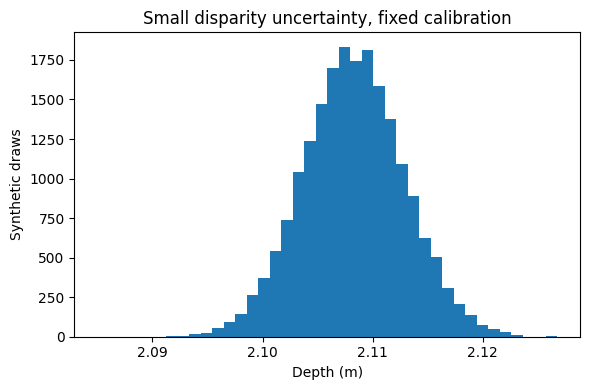

In [6]:
known=np.c_[rng.uniform(-.8,.8,120),rng.uniform(-.5,.5,120),rng.uniform(2,5,120)]
uv_true,_=project(known,np.array(calibration["K_left"]))
uv_noisy=uv_true+rng.normal(0,.2,uv_true.shape)
train=np.arange(80);hold=np.arange(80,120)
Ax=np.c_[known[:,0]/known[:,2],np.ones(len(known))];Ay=np.c_[known[:,1]/known[:,2],np.ones(len(known))]
fx,cx=np.linalg.lstsq(Ax[train],uv_noisy[train,0],rcond=None)[0]
fy,cy=np.linalg.lstsq(Ay[train],uv_noisy[train,1],rcond=None)[0]
Kfit=np.array([[fx,0,cx],[0,fy,cy],[0,0,1.]])
uv_hold,_=project(known[hold],Kfit)
hold_rmse=float(np.sqrt(np.mean(np.sum((uv_hold-uv_true[hold])**2,axis=1))))
d0=60.;sigma=.2;draws=rng.normal(d0,sigma,20000)
sim_z=depth_from_disparity(draws,f,B,off)
pred_sigma=f*B/(d0+off)**2*sigma
emp_sigma=float(np.std(sim_z,ddof=1))
assert np.isclose(emp_sigma,pred_sigma,rtol=.05)
print("Synthetic held-out intrinsic-fit pixel RMSE:",hold_rmse)
print("Conditional depth SD, formula and simulation:",pred_sigma,emp_sigma)
plt.figure(figsize=(6,4));plt.hist(sim_z,bins=40)
plt.xlabel("Depth (m)");plt.ylabel("Synthetic draws");plt.title("Small disparity uncertainty, fixed calibration")
show_and_save(OUT / "depth_uncertainty.png")

## 5. Unsynchronized views of a moving point — synthetic
A moving point observed at different times is not the same triangulation problem as a static point. Here the point moves horizontally, so the mismatch changes disparity without creating a vertical epipolar residual. A small reprojection residual therefore need not prove synchronized geometry.

Synthetic offsets (s): [0.    0.002 0.005 0.01  0.02 ] position errors (m): [9.053594779595603e-16, 0.04736817174646646, 0.12129314666767055, 0.25280756849680586, 0.5521438518782102]


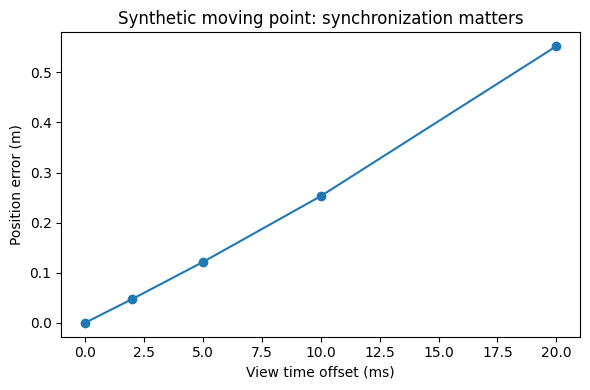

In [7]:
X0=np.array([[0.,0.,3.]])
uv0,_=project(X0,np.array(calibration["K_left"]))
deltas=np.array([0.,.002,.005,.01,.02]);errors=[]
for dt in deltas:
    moved_point=X0+np.array([[1.5*dt,0,0]])
    uv_r,_=project(transform_points(np.array(calibration["T_right_left"]),moved_point),np.array(calibration["K_right"]))
    estimate=triangulate_dlt(P1,P2,uv0,uv_r)
    errors.append(float(np.linalg.norm(estimate-X0)))
print("Synthetic offsets (s):",deltas,"position errors (m):",errors)
plt.figure(figsize=(6,4));plt.plot(deltas*1000,errors,marker="o")
plt.xlabel("View time offset (ms)");plt.ylabel("Position error (m)");plt.title("Synthetic moving point: synchronization matters")
show_and_save(OUT / "synchronization_error.png")
save_json(OUT / "results.json", {"real_data":"Middlebury motorcycle via scikit-image", "sample_count":len(sample_rc),"matcher":"integer SAD, radius=3, max_disparity=128, fixed grid", "disparity":metrics,"depth_mae_m":depth_mae,"omitted_offset_median_relative_error":wrong_relative,"triangulation_reference_formula_max_difference_m":tri_error,"synthetic_intrinsics_holdout_rmse_px":hold_rmse,"synthetic_depth_sd_formula_m":pred_sigma,"synthetic_depth_sd_monte_carlo_m":emp_sigma,"synthetic_sync_offsets_s":deltas,"synthetic_sync_errors_m":errors,"limitations":["Single exposed static scene; not a general benchmark","No occlusion or subpixel refinement","Reference-derived formula agreement is a consistency check, not independent metric truth","Synthetic calibration has known camera-frame coordinates"]})

## Explain before continuing
Which errors did the SAD matcher make? Does a larger margin mean a calibrated confidence probability? Which uncertainty sources are missing from the one-variable Monte Carlo? Why are the DLT and depth-formula results not independent truth sources?